# Release Conditions Deep Dive: Understanding Access Control Patterns

This notebook provides a detailed analysis of release conditions in the BCIT LMS, focusing on:
- **Functional descriptions** of each release condition type
- **Usage patterns** across organizational units
- **Common use cases** and pedagogical intent
- **Best practices** for implementing access controls

Based on the BCIT LMS Data Dictionary - Release Conditions section.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 10)
pd.set_option('display.max_columns', None)

## 1. Load Release Conditions Data

In [3]:
base_path = Path('../etl-output')
release_conditions_path = base_path / 'releaseconditions/releaseconditionsobjects/data'

print("Loading Release Conditions dataset...")
release_files = sorted(glob.glob(str(release_conditions_path / 'part-*.csv')))
print(f"Found {len(release_files)} release condition files")

release_conditions = pd.concat(
    [pd.read_csv(f, low_memory=False) for f in release_files],
    ignore_index=True
)
print(f"Loaded {len(release_conditions):,} release conditions")
print(f"Columns: {list(release_conditions.columns)}")
release_conditions.head()

Loading Release Conditions dataset...
Found 4 release condition files
Loaded 171,691 release conditions
Columns: ['pre_requisite_id', 'result_id', 'org_unit_id', 'name', 'is_negative_condition', 'pre_requisite_tool_id', 'id1', 'id2', 'result_tool_id', 'uses_percentage', 'operator_type_desc', 'version', 'guid1', 'guid2']


,pre_requisite_id,result_id,org_unit_id,name,is_negative_condition,pre_requisite_tool_id,id1,id2,result_tool_id,uses_percentage,operator_type_desc,version,guid1,guid2
0,124333,185672,1213612,Group Membership,False,11000,1213867,0,51000,False,All,5937828924,NaN,NaN
1,124332,185671,1213612,Group Membership,False,11000,1213866,0,51000,False,All,5937828923,NaN,NaN
2,124331,185670,1213612,Discussion posts to topic / forum,False,3000,513639,157334,694000,False,All,5937828922,NaN,NaN
3,124330,185669,1213612,Discussion posts to topic / forum,False,3000,513644,157334,694000,False,All,5937828921,NaN,NaN
4,124329,185666,1213612,Discussion posts to topic / forum,False,3000,513642,157334,694000,False,All,5937828918,NaN,NaN


## 2. Release Condition Type Distribution with Functional Descriptions

In [4]:
# Define detailed descriptions for each release condition type
condition_descriptions = {
    'Mark on a Quiz': {
        'description': 'Requires students to achieve a specific score on a quiz',
        'use_case': 'Used for mastery-based learning; students must demonstrate proficiency before advancing',
        'typical_users': 'Instructors implementing prerequisite knowledge checks or competency-based progression'
    },
    'Completed Quiz Attempt': {
        'description': 'Requires students to complete a quiz attempt (regardless of score)',
        'use_case': 'Ensures engagement with assessment content; focuses on participation over performance',
        'typical_users': 'Instructors who want to ensure exposure to material without grade barriers'
    },
    'Content topic visited': {
        'description': 'Requires students to access/view a specific content topic',
        'use_case': 'Tracks learning path adherence; ensures students view critical materials',
        'typical_users': 'Instructors enforcing sequential learning or mandatory content review'
    },
    'Submission to dropbox': {
        'description': 'Requires students to submit an assignment to a dropbox',
        'use_case': 'Gates access to subsequent materials until work is submitted; encourages timely completion',
        'typical_users': 'Instructors using scaffolded assignments or project-based learning'
    },
    'Section Enrollment': {
        'description': 'Restricts access based on which section/cohort a student is enrolled in',
        'use_case': 'Differentiates content for different student groups (e.g., honors vs. standard sections)',
        'typical_users': 'Programs with multiple sections, differentiated instruction, or lab groups'
    },
    'Group Membership': {
        'description': 'Restricts access based on group assignment within the course',
        'use_case': 'Provides group-specific materials; supports collaborative learning with distinct resources',
        'typical_users': 'Instructors managing team projects, case studies, or specialized working groups'
    },
    'Enrolled in current orgUnit as': {
        'description': 'Restricts access based on enrollment role (student, TA, instructor, auditor)',
        'use_case': 'Differentiates content by role; provides instructor-only materials or TA resources',
        'typical_users': 'Course designers creating role-specific resources (e.g., instructor guides, TA answer keys)'
    },
    'Content topic completed': {
        'description': 'Requires completion of a content topic (marked as complete by student or system)',
        'use_case': 'Ensures thorough engagement; students must actively mark content as reviewed',
        'typical_users': 'Instructors emphasizing self-directed learning and accountability'
    },
    'Mark on a Grade Item': {
        'description': 'Requires a specific grade on any gradebook item',
        'use_case': 'Broader than quiz-specific; can gate based on any assessed activity',
        'typical_users': 'Instructors using diverse assessment types (discussions, projects, presentations)'
    },
    'Discussion posts to topic / forum': {
        'description': 'Requires a minimum number of discussion posts in a specific forum/topic',
        'use_case': 'Encourages peer interaction and community building before accessing advanced content',
        'typical_users': 'Instructors prioritizing collaborative learning and social constructivism'
    }
}

# Get top 10 release condition types
condition_counts = release_conditions['name'].value_counts().head(10)
print("Top 10 Release Condition Types:")
print(condition_counts)

Top 10 Release Condition Types:
name
Mark on a Quiz                       26550
Completed Quiz Attempt               25507
Content topic visited                24337
Submission to dropbox                20585
Section Enrollment                   17862
Group Membership                     17141
Enrolled in current orgUnit as       16043
Content topic completed               5429
Mark on a Grade Item                  4668
Discussion posts to topic / forum     4415
Name: count, dtype: int64


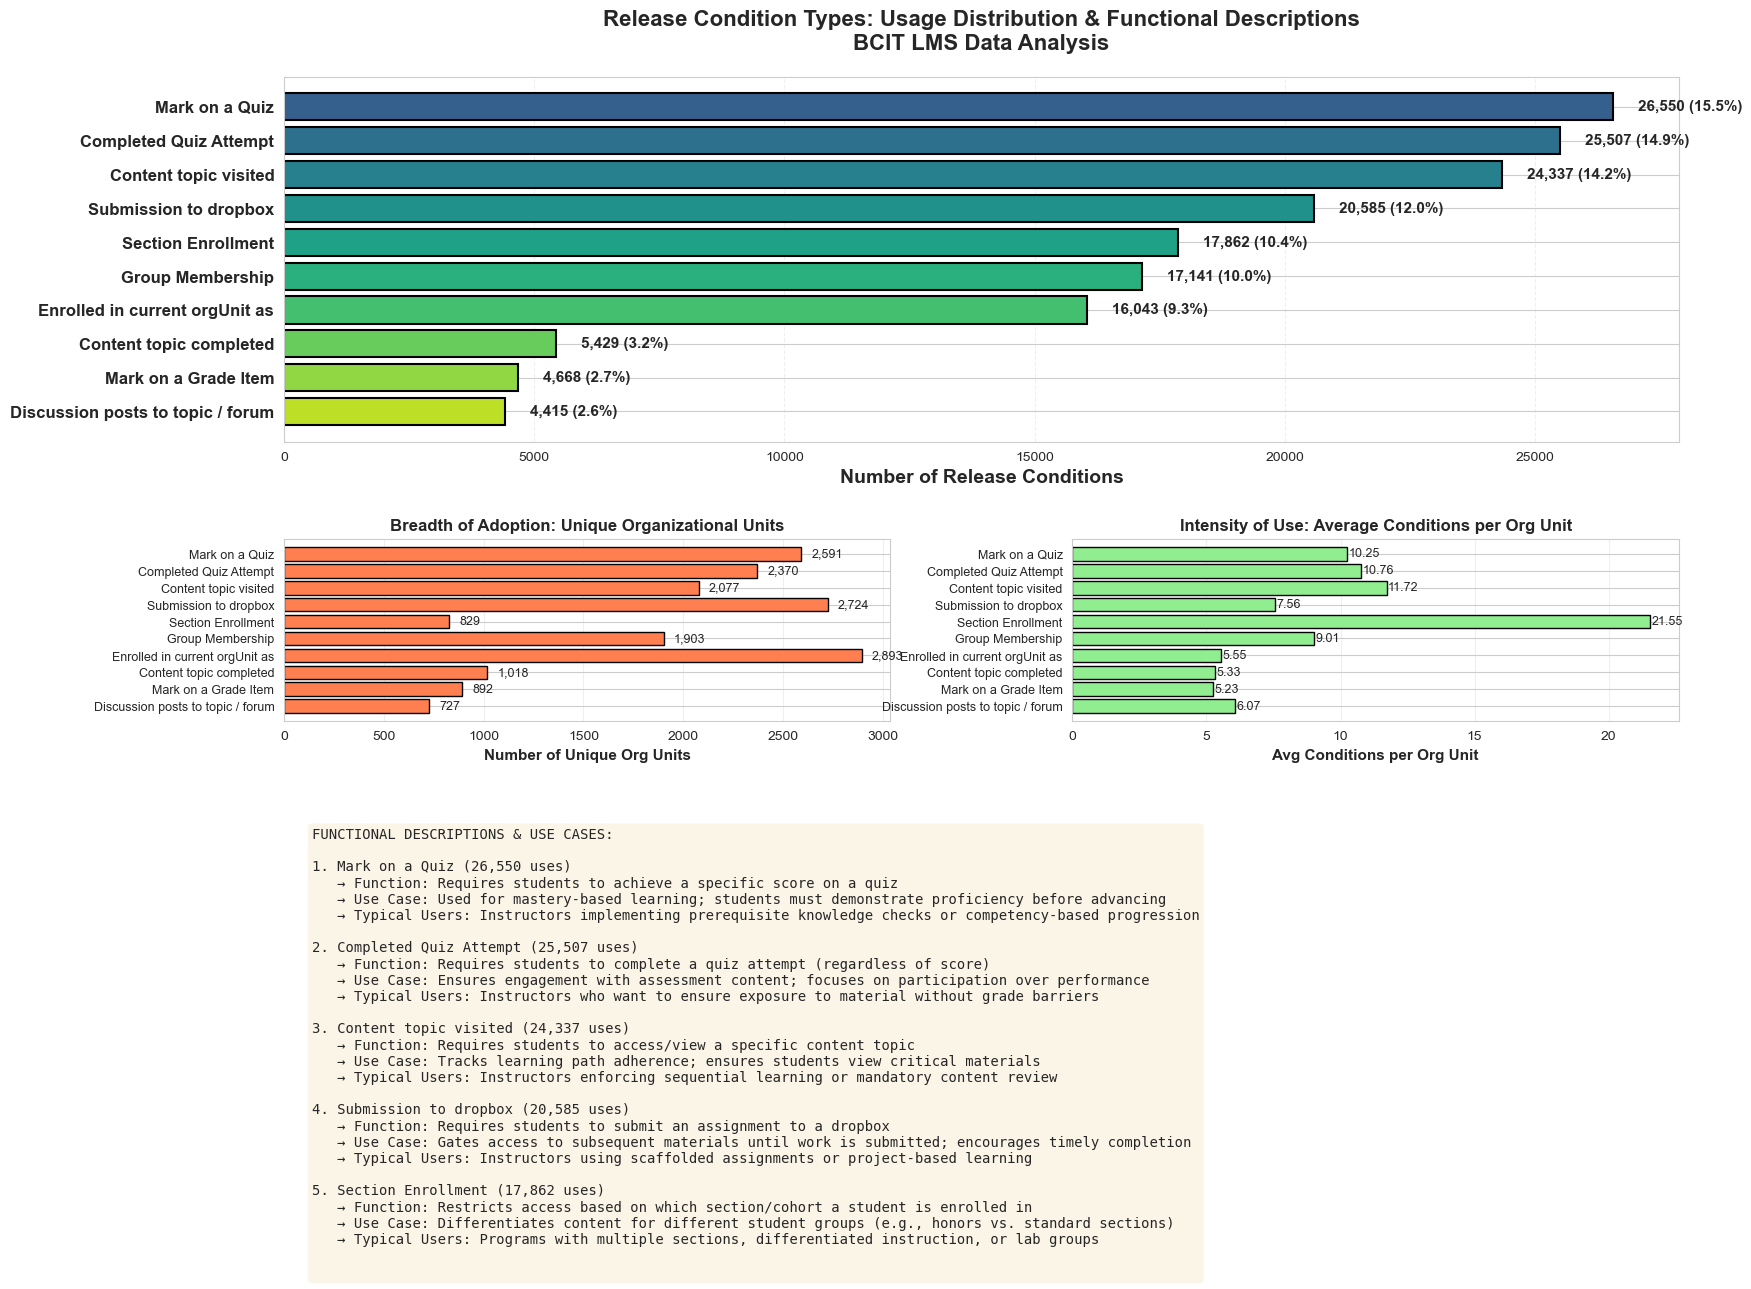

In [5]:
# Create comprehensive visualization with annotations
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[2, 1, 1], hspace=0.4, wspace=0.3)

# Main bar chart
ax1 = fig.add_subplot(gs[0, :])
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(condition_counts)))
bars = ax1.barh(range(len(condition_counts)), condition_counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_yticks(range(len(condition_counts)))
ax1.set_yticklabels(condition_counts.index, fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Release Conditions', fontsize=14, fontweight='bold')
ax1.set_title('Release Condition Types: Usage Distribution & Functional Descriptions\nBCIT LMS Data Analysis', 
              fontsize=16, fontweight='bold', pad=20)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Add count labels
for i, (idx, count) in enumerate(condition_counts.items()):
    percentage = (count / len(release_conditions)) * 100
    ax1.text(count + 500, i, f'{count:,} ({percentage:.1f}%)', 
            va='center', fontsize=11, fontweight='bold')

# Calculate organizational units using each condition type
org_unit_usage = release_conditions.groupby('name')['org_unit_id'].nunique()
top_org_usage = org_unit_usage[condition_counts.index]

# Organizational units chart
ax2 = fig.add_subplot(gs[1, 0])
ax2.barh(range(len(top_org_usage)), top_org_usage.values, color='coral', edgecolor='black', linewidth=1)
ax2.set_yticks(range(len(top_org_usage)))
ax2.set_yticklabels(top_org_usage.index, fontsize=9)
ax2.set_xlabel('Number of Unique Org Units', fontsize=11, fontweight='bold')
ax2.set_title('Breadth of Adoption: Unique Organizational Units', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)
for i, count in enumerate(top_org_usage.values):
    ax2.text(count + 50, i, f'{count:,}', va='center', fontsize=9)

# Average conditions per org unit
avg_per_org = release_conditions.groupby('name').apply(
    lambda x: len(x) / x['org_unit_id'].nunique()
).loc[condition_counts.index]

ax3 = fig.add_subplot(gs[1, 1])
ax3.barh(range(len(avg_per_org)), avg_per_org.values, color='lightgreen', edgecolor='black', linewidth=1)
ax3.set_yticks(range(len(avg_per_org)))
ax3.set_yticklabels(avg_per_org.index, fontsize=9)
ax3.set_xlabel('Avg Conditions per Org Unit', fontsize=11, fontweight='bold')
ax3.set_title('Intensity of Use: Average Conditions per Org Unit', fontsize=12, fontweight='bold')
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)
for i, val in enumerate(avg_per_org.values):
    ax3.text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=9)

# Description panel
ax4 = fig.add_subplot(gs[2, :])
ax4.axis('off')

# Create description text
description_text = "FUNCTIONAL DESCRIPTIONS & USE CASES:\n\n"
for i, condition_name in enumerate(condition_counts.index[:5], 1):
    if condition_name in condition_descriptions:
        desc = condition_descriptions[condition_name]
        description_text += f"{i}. {condition_name} ({condition_counts[condition_name]:,} uses)\n"
        description_text += f"   → Function: {desc['description']}\n"
        description_text += f"   → Use Case: {desc['use_case']}\n"
        description_text += f"   → Typical Users: {desc['typical_users']}\n\n"

ax4.text(0.02, 0.95, description_text, transform=ax4.transAxes, 
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

## 3. Deep Dive: "Enrolled in current orgUnit as" Analysis

Total 'Enrolled in current orgUnit as' conditions: 16,043
Unique organizational units using this: 2,893
Average uses per org unit: 5.55

Operator types for 'Enrolled in current orgUnit as':
operator_type_desc
All    14142
Any     1901
Name: count, dtype: int64

Positive conditions (IS enrolled as): 16,043
Negative conditions (NOT enrolled as): 0


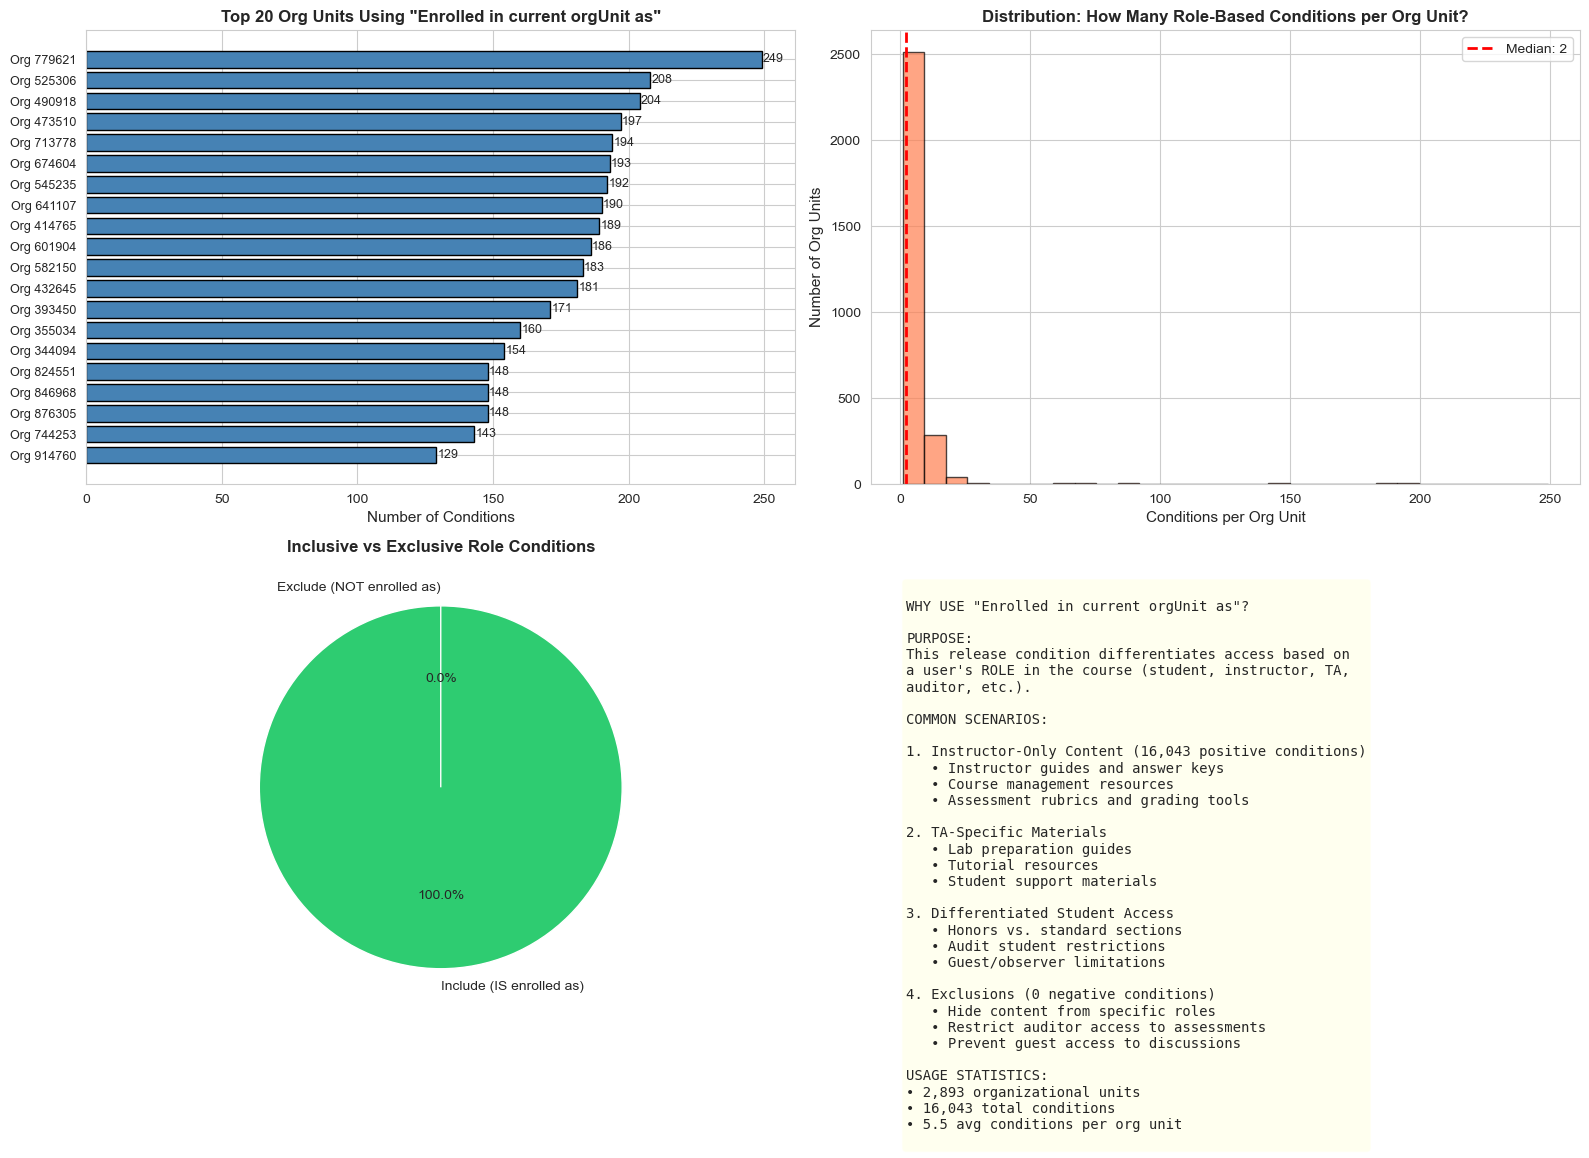

In [6]:
# Analyze "Enrolled in current orgUnit as" - a role-based condition
enrolled_as_conditions = release_conditions[
    release_conditions['name'] == 'Enrolled in current orgUnit as'
].copy()

print(f"Total 'Enrolled in current orgUnit as' conditions: {len(enrolled_as_conditions):,}")
print(f"Unique organizational units using this: {enrolled_as_conditions['org_unit_id'].nunique():,}")
print(f"Average uses per org unit: {len(enrolled_as_conditions) / enrolled_as_conditions['org_unit_id'].nunique():.2f}")

# Analyze operator types for this condition
if 'operator_type_desc' in enrolled_as_conditions.columns:
    print("\nOperator types for 'Enrolled in current orgUnit as':")
    print(enrolled_as_conditions['operator_type_desc'].value_counts())

# Analyze negative conditions (NOT enrolled as)
if 'is_negative_condition' in enrolled_as_conditions.columns:
    negative_count = enrolled_as_conditions['is_negative_condition'].sum()
    positive_count = len(enrolled_as_conditions) - negative_count
    print(f"\nPositive conditions (IS enrolled as): {positive_count:,}")
    print(f"Negative conditions (NOT enrolled as): {negative_count:,}")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Usage over organizational units
org_usage = enrolled_as_conditions.groupby('org_unit_id').size().sort_values(ascending=False).head(20)
axes[0, 0].barh(range(len(org_usage)), org_usage.values, color='steelblue', edgecolor='black')
axes[0, 0].set_yticks(range(len(org_usage)))
axes[0, 0].set_yticklabels([f"Org {int(x)}" for x in org_usage.index], fontsize=9)
axes[0, 0].set_xlabel('Number of Conditions', fontsize=11)
axes[0, 0].set_title('Top 20 Org Units Using "Enrolled in current orgUnit as"', 
                     fontsize=12, fontweight='bold')
axes[0, 0].invert_yaxis()
for i, val in enumerate(org_usage.values):
    axes[0, 0].text(val + 0.5, i, f'{val}', va='center', fontsize=9)

# Distribution of conditions per org unit
conditions_per_org = enrolled_as_conditions.groupby('org_unit_id').size()
axes[0, 1].hist(conditions_per_org, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Conditions per Org Unit', fontsize=11)
axes[0, 1].set_ylabel('Number of Org Units', fontsize=11)
axes[0, 1].set_title('Distribution: How Many Role-Based Conditions per Org Unit?', 
                     fontsize=12, fontweight='bold')
axes[0, 1].axvline(conditions_per_org.median(), color='red', linestyle='--', 
                   linewidth=2, label=f'Median: {conditions_per_org.median():.0f}')
axes[0, 1].legend()

# Positive vs Negative conditions
if 'is_negative_condition' in enrolled_as_conditions.columns:
    condition_type = enrolled_as_conditions['is_negative_condition'].value_counts()
    labels = ['Include (IS enrolled as)', 'Exclude (NOT enrolled as)']
    colors_pie = ['#2ecc71', '#e74c3c']
    axes[1, 0].pie([positive_count, negative_count], labels=labels, autopct='%1.1f%%', 
                   colors=colors_pie, startangle=90)
    axes[1, 0].set_title('Inclusive vs Exclusive Role Conditions', fontsize=12, fontweight='bold')

# Text explanation
axes[1, 1].axis('off')
explanation = f"""
WHY USE "Enrolled in current orgUnit as"?

PURPOSE:
This release condition differentiates access based on 
a user's ROLE in the course (student, instructor, TA, 
auditor, etc.).

COMMON SCENARIOS:

1. Instructor-Only Content ({positive_count:,} positive conditions)
   • Instructor guides and answer keys
   • Course management resources
   • Assessment rubrics and grading tools

2. TA-Specific Materials
   • Lab preparation guides
   • Tutorial resources
   • Student support materials

3. Differentiated Student Access
   • Honors vs. standard sections
   • Audit student restrictions
   • Guest/observer limitations

4. Exclusions ({negative_count:,} negative conditions)
   • Hide content from specific roles
   • Restrict auditor access to assessments
   • Prevent guest access to discussions

USAGE STATISTICS:
• {enrolled_as_conditions['org_unit_id'].nunique():,} organizational units
• {len(enrolled_as_conditions):,} total conditions
• {len(enrolled_as_conditions) / enrolled_as_conditions['org_unit_id'].nunique():.1f} avg conditions per org unit
"""

axes[1, 1].text(0.05, 0.95, explanation, transform=axes[1, 1].transAxes,
               fontsize=10, verticalalignment='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

plt.tight_layout()
plt.show()

## 4. Pedagogical Patterns: Combining Multiple Conditions

Conditions per Result Item:
condition_count
1     108576
2       8724
3       2874
4       1441
5        607
6        770
7        306
8        239
9        194
10       199
Name: count, dtype: int64


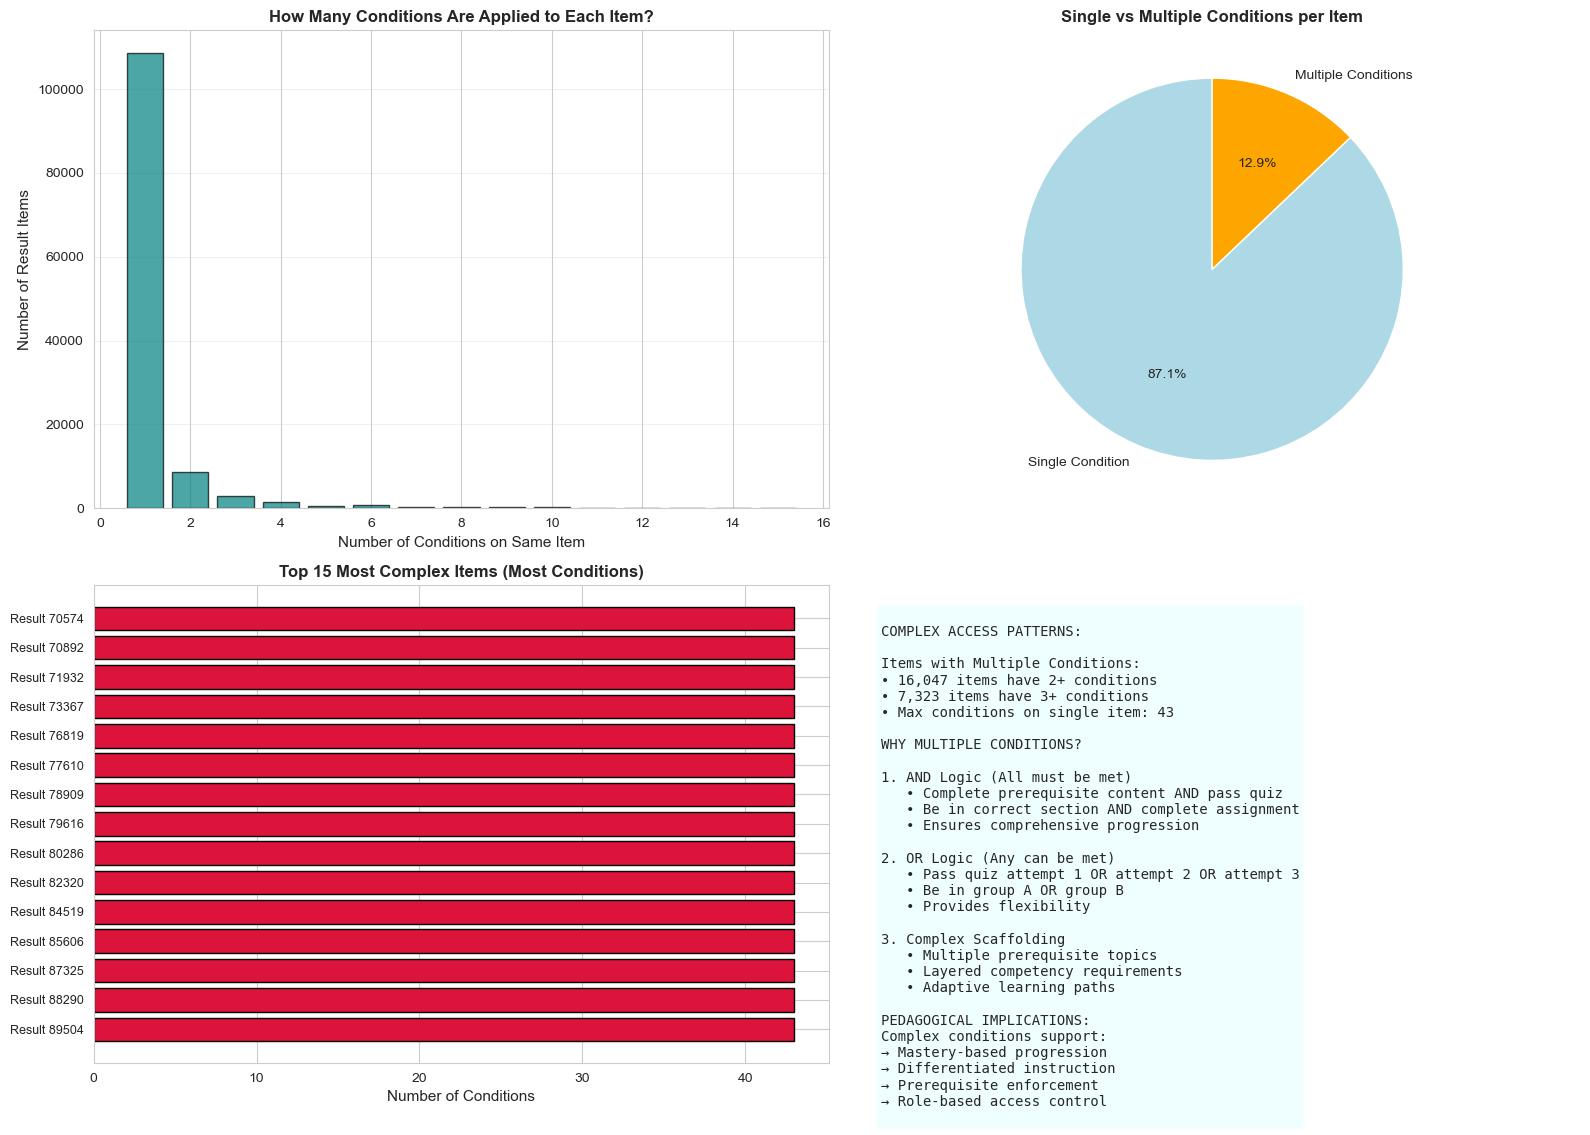

In [7]:
# Analyze how many conditions are applied to the same result
conditions_per_result = release_conditions.groupby('result_id').agg({
    'name': 'count',
    'org_unit_id': 'first'
}).rename(columns={'name': 'condition_count'})

print("Conditions per Result Item:")
print(conditions_per_result['condition_count'].value_counts().sort_index().head(10))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribution of multiple conditions
condition_count_dist = conditions_per_result['condition_count'].value_counts().sort_index().head(15)
axes[0, 0].bar(condition_count_dist.index, condition_count_dist.values, 
               color='teal', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Number of Conditions on Same Item', fontsize=11)
axes[0, 0].set_ylabel('Number of Result Items', fontsize=11)
axes[0, 0].set_title('How Many Conditions Are Applied to Each Item?', 
                     fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Percentage breakdown
multi_condition_items = (conditions_per_result['condition_count'] > 1).sum()
single_condition_items = (conditions_per_result['condition_count'] == 1).sum()
axes[0, 1].pie([single_condition_items, multi_condition_items], 
               labels=['Single Condition', 'Multiple Conditions'],
               autopct='%1.1f%%', colors=['lightblue', 'orange'], startangle=90)
axes[0, 1].set_title('Single vs Multiple Conditions per Item', 
                     fontsize=12, fontweight='bold')

# Most complex items (most conditions)
most_complex = conditions_per_result.nlargest(15, 'condition_count')
axes[1, 0].barh(range(len(most_complex)), most_complex['condition_count'].values, 
                color='crimson', edgecolor='black')
axes[1, 0].set_yticks(range(len(most_complex)))
axes[1, 0].set_yticklabels([f"Result {int(x)}" for x in most_complex.index], fontsize=9)
axes[1, 0].set_xlabel('Number of Conditions', fontsize=11)
axes[1, 0].set_title('Top 15 Most Complex Items (Most Conditions)', 
                     fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()

# Analysis of condition combinations
axes[1, 1].axis('off')
multi_conditions_text = f"""
COMPLEX ACCESS PATTERNS:

Items with Multiple Conditions:
• {multi_condition_items:,} items have 2+ conditions
• {(conditions_per_result['condition_count'] >= 3).sum():,} items have 3+ conditions
• Max conditions on single item: {conditions_per_result['condition_count'].max()}

WHY MULTIPLE CONDITIONS?

1. AND Logic (All must be met)
   • Complete prerequisite content AND pass quiz
   • Be in correct section AND complete assignment
   • Ensures comprehensive progression

2. OR Logic (Any can be met)
   • Pass quiz attempt 1 OR attempt 2 OR attempt 3
   • Be in group A OR group B
   • Provides flexibility

3. Complex Scaffolding
   • Multiple prerequisite topics
   • Layered competency requirements
   • Adaptive learning paths

PEDAGOGICAL IMPLICATIONS:
Complex conditions support:
→ Mastery-based progression
→ Differentiated instruction
→ Prerequisite enforcement
→ Role-based access control
"""

axes[1, 1].text(0.05, 0.95, multi_conditions_text, transform=axes[1, 1].transAxes,
               fontsize=10, verticalalignment='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.5))

plt.tight_layout()
plt.show()

## 5. Summary: Key Insights and Recommendations

In [8]:
print("="*80)
print("RELEASE CONDITIONS ANALYSIS: KEY INSIGHTS")
print("="*80)

print("\n1. OVERALL STATISTICS:")
print(f"   Total Release Conditions: {len(release_conditions):,}")
print(f"   Unique Condition Types: {release_conditions['name'].nunique()}")
print(f"   Organizational Units Using Conditions: {release_conditions['org_unit_id'].nunique():,}")
print(f"   Items with Conditions: {release_conditions['result_id'].nunique():,}")

print("\n2. TOP 5 CONDITION TYPES:")
for i, (name, count) in enumerate(condition_counts.head(5).items(), 1):
    percentage = (count / len(release_conditions)) * 100
    org_count = org_unit_usage[name]
    print(f"   {i}. {name}")
    print(f"      Usage: {count:,} ({percentage:.1f}%) | Org Units: {org_count:,}")
    if name in condition_descriptions:
        print(f"      Purpose: {condition_descriptions[name]['description']}")

print("\n3. COMPLEXITY METRICS:")
print(f"   Items with Single Condition: {single_condition_items:,}")
print(f"   Items with Multiple Conditions: {multi_condition_items:,}")
print(f"   Average Conditions per Item: {conditions_per_result['condition_count'].mean():.2f}")
print(f"   Maximum Conditions on One Item: {conditions_per_result['condition_count'].max()}")

print("\n4. ROLE-BASED ACCESS ('Enrolled in current orgUnit as'):")
enrolled_count = len(enrolled_as_conditions)
enrolled_org_count = enrolled_as_conditions['org_unit_id'].nunique()
print(f"   Total Uses: {enrolled_count:,}")
print(f"   Organizational Units: {enrolled_org_count:,}")
print(f"   Primary Purpose: Role-based content differentiation (instructor/TA/student)")

print("\n5. RECOMMENDATIONS:")
print("   → Assessment-Based Conditions (Quizzes): Most common - supports mastery learning")
print("   → Content Tracking: High usage indicates emphasis on sequential learning")
print("   → Role-Based: Enables instructor resources and differentiated materials")
print("   → Multiple Conditions: Support complex learning paths and prerequisites")

print("\n" + "="*80)

RELEASE CONDITIONS ANALYSIS: KEY INSIGHTS

1. OVERALL STATISTICS:
   Total Release Conditions: 171,691
   Unique Condition Types: 30
   Organizational Units Using Conditions: 13,511
   Items with Conditions: 124,623

2. TOP 5 CONDITION TYPES:
   1. Mark on a Quiz
      Usage: 26,550 (15.5%) | Org Units: 2,591
      Purpose: Requires students to achieve a specific score on a quiz
   2. Completed Quiz Attempt
      Usage: 25,507 (14.9%) | Org Units: 2,370
      Purpose: Requires students to complete a quiz attempt (regardless of score)
   3. Content topic visited
      Usage: 24,337 (14.2%) | Org Units: 2,077
      Purpose: Requires students to access/view a specific content topic
   4. Submission to dropbox
      Usage: 20,585 (12.0%) | Org Units: 2,724
      Purpose: Requires students to submit an assignment to a dropbox
   5. Section Enrollment
      Usage: 17,862 (10.4%) | Org Units: 829
      Purpose: Restricts access based on which section/cohort a student is enrolled in

3. COMPLE